In [12]:
import pandas as pd
import numpy as np
import os

import optuna
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw
import itertools

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import random

In [13]:
#!pip install matplotlib scikit-learn pandas seaborn optuna

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# DATASET PREPARATION

In [15]:
def read_img_labels(xml_path):
    XMLtree = ET.parse(xml_path)
    XMLroot = XMLtree.getroot()
    img_labels = []

    for obj in XMLroot.findall('object'):
        label_name = obj.find('name').text
        bounding_box = obj.find('bndbox')
        
        x_min = int(bounding_box.find('xmin').text)
        y_min = int(bounding_box.find('ymin').text)
        x_max = int(bounding_box.find('xmax').text)
        y_max = int(bounding_box.find('ymax').text)

        img_labels.append((label_name, (x_min, y_min, x_max, y_max)))

    return img_labels

In [16]:
def read_files(files):
    data = []
    dimensions = []

    for file_name in files:
        img_path = os.path.join(data_directory, 'Images', file_name + '.jpg')
        xml_path = os.path.join(data_directory, 'Labels', 'Horizontal Bounding Boxes', file_name + '.xml')

        image = Image.open(img_path)
        image_array = np.array(image)
        if (image_array.shape[2]) != 3:
            continue

        img_labels = read_img_labels(xml_path)

        for label in img_labels:
            width = abs(label[1][0] - label[1][2])
            height = abs(label[1][1] - label[1][3])
            dimensions.append(width)
            dimensions.append(height)

        data.append((image, img_labels))

    return data, dimensions

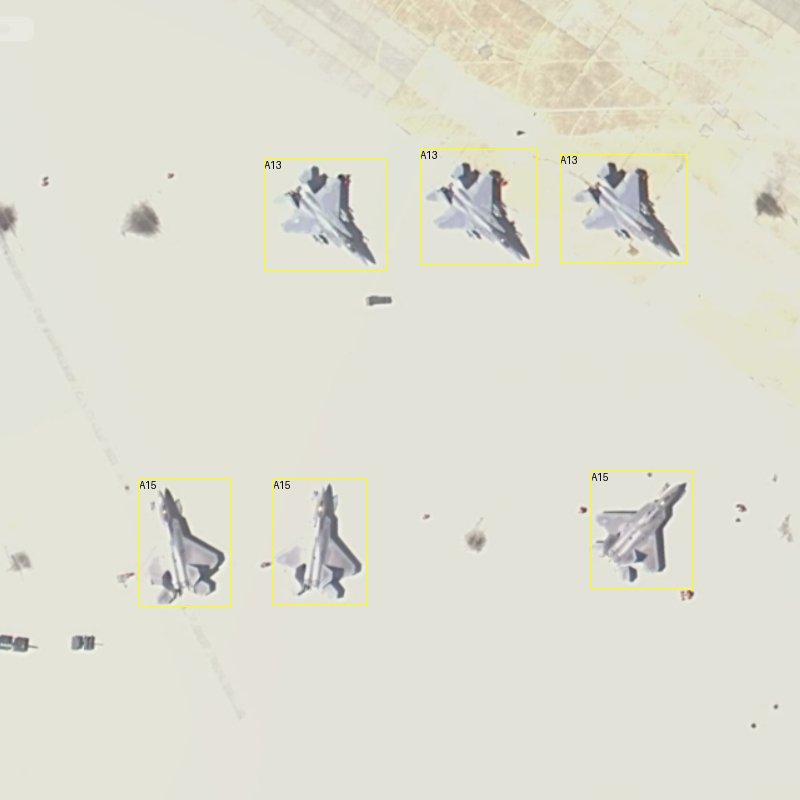

In [17]:
data_directory = './datasets'

with open(os.path.join(data_directory, 'ImageSets/Main/train.txt'), 'r') as f:
    train_fnames = f.read().splitlines()
    
train_data, train_obj_dimensions = read_files(train_fnames)

image = train_data[3][0]
img_to_draw = ImageDraw.Draw(image)
img_objects = train_data[3][1]

for obj in img_objects:
    img_to_draw.text((obj[1][0], obj[1][1]), obj[0], fill='black')
    img_to_draw.rectangle(obj[1], outline='yellow')
image

# PREPROCESSING

In [18]:
def square_img(image):
    image_original_size = image.size
    image_desired_size = (64, 64)

    image_max_dimension = max(image_original_size)

    squares = Image.new("RGB", (image_max_dimension, image_max_dimension))

    x = (image_max_dimension - image_original_size[0]) // 2
    y = (image_max_dimension - image_original_size[1]) // 2
    squares.paste(image, (x, y))

    new_image = squares.resize(image_desired_size)

    return new_image

In [19]:
def object_from_image(image, image_labels):
    objects = []
    labels = []

    for label, bounding_box in image_labels:
        labels.append(label)
        obj_region = image.crop(bounding_box)
        objects.append(obj_region)

    labels = np.array(labels)

    return objects, labels

In [20]:
def data_prep(data):
    X_temporary = []
    y_temporary = []

    for image, image_labels in data:
        objects, labels = object_from_image(image, image_labels)

        squares = []
        for obj in objects:
            square_image = square_img(obj)
            squares.append(square_image)

        X_temporary.append(squares)
        y_temporary.append(labels)

    original_labels = list(itertools.chain(*y_temporary))
    original_labels_np = np.array(original_labels).reshape(-1, 1)

    OHEncoder = OneHotEncoder()
    y = OHEncoder.fit_transform(original_labels_np).toarray()

    n_channels = 4
    X_list = []

    for image in X_temporary:
        for obj in image:
            X_list.append(np.array(obj)/255.0)

    X = np.array(X_list)

    return X, y, original_labels_np

Liczba klas: 20


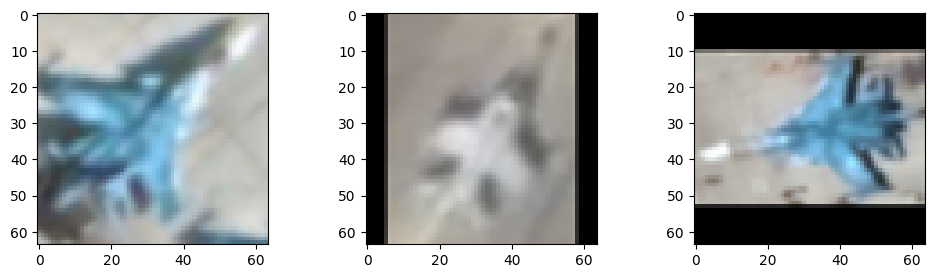

In [21]:
X, y, original_labels = data_prep(train_data)
n_labels = y.shape[1]
print("Liczba klas:", n_labels)

fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(12, 3))
ax0.imshow(X[3], cmap='gray')
ax1.imshow(X[43], cmap='gray')
ax2.imshow(X[80], cmap='gray')

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.7, random_state=10)

print("Dane treningowe:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print("Dane testowe:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Dane treningowe:
X_train: (5468, 64, 64, 3)
y_train: (5468, 20)
Dane testowe:
X_test: (2344, 64, 64, 3)
y_test: (2344, 20)


# MODEL

In [23]:
class CNN(nn.Module):
    def __init__(self, conv_layers, filters, kernel_sizes, strides, dense_units, dropout_rate):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential()
        
        in_channels = 3
        for i in range(conv_layers):
            out_channels = filters[i]
            kernel_size = kernel_sizes[i]
            stride = strides[i]
            self.conv_layers.add_module(f'conv{i+1}', nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=1))
            self.conv_layers.add_module(f'relu{i+1}', nn.ReLU())
            self.conv_layers.add_module(f'pool{i+1}', nn.AvgPool2d(kernel_size=2, stride=2))
            in_channels = out_channels
        
        self.flatten = nn.Flatten()
        
        self._to_linear = self.calculate_linear_input(conv_layers, filters, kernel_sizes, strides)
        
        self.fc1 = nn.Linear(self._to_linear, dense_units)
        self.fc2 = nn.Linear(dense_units, 20)
        
        self.dropout = nn.Dropout(dropout_rate)
    
    def calculate_linear_input(self, conv_layers, filters, kernel_sizes, strides):
        size = 64 
        for i in range(conv_layers):
            size = (size - kernel_sizes[i] + 2 * 1) // strides[i] + 1
            size = size // 2
        return filters[-1] * size * size
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [24]:
def create_model(conv_layers, filters, kernel_sizes, strides, dense_units, dropout_rate):
    model = CNN(conv_layers, filters, kernel_sizes, strides, dense_units, dropout_rate)
    return model

In [25]:
# conv_layers_best = best_trial_params['conv_layers']
# filters_best = [best_trial_params[f'filters_{i}'] for i in range(conv_layers_best)]
# kernel_sizes_best = [best_trial_params[f'kernel_size_{i}'] for i in range(conv_layers_best)]
# strides_best = [best_trial_params[f'stride_{i}'] for i in range(conv_layers_best)]
# dense_units_best = best_trial_params['units']
# dropout_rate_best = best_trial_params['dropout']

# best_model_manual_params = create_model(conv_layers_best,
#                                         filters_best,
#                                         kernel_sizes_best,
#                                         strides_best,
#                                         dense_units_best,
#                                         dropout_rate_best).to(device)
# print(best_model_manual_params)


# Teraz możesz ręcznie uruchomić model z własnymi parametrami:
manual_conv_layers = 3
manual_filters = [96, 64, 96]
manual_kernel_sizes = [2, 3, 2]
manual_strides = [1, 1, 1]
manual_dense_units = 64
manual_dropout_rate = 0.5

manual_model = create_model(manual_conv_layers,
                            manual_filters,
                            manual_kernel_sizes,
                            manual_strides,
                            manual_dense_units,
                            manual_dropout_rate).to(device)

print(manual_model)

CNN(
  (conv_layers): Sequential(
    (conv1): Conv2d(3, 96, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (relu1): ReLU()
    (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (conv2): Conv2d(96, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu2): ReLU()
    (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (conv3): Conv2d(64, 96, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (relu3): ReLU()
    (pool3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=6144, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=20, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [26]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
y_train_tensor = torch.tensor(y_train.argmax(axis=1), dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)
y_test_tensor = torch.tensor(y_test.argmax(axis=1), dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Optymalizator i funkcja straty
optimizer = optim.Adam(manual_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(11):
    manual_model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = manual_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_loader)
    if epoch % 5 == 0:
        print(f'Epoch {epoch}, Training Loss: {avg_train_loss:.4f}')
    
    manual_model.eval()
    correct = 0
    total = 0
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = manual_model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    
    avg_val_loss = val_loss / len(test_loader)
    accuracy = correct / total
    if epoch % 5 == 0:
        print(f'Epoch {epoch}, Validation Loss: {avg_val_loss:.4f}, Accuracy: {accuracy:.4f}')

manual_model.eval()
predictions = []
with torch.no_grad():
    for X_batch in test_loader:
        X_batch = X_batch[0].to(device)
        outputs = manual_model(X_batch)
        _, predicted = torch.max(outputs.data, 1)
        predictions.extend(predicted.cpu().numpy())

Epoch 0, Training Loss: 2.2091
Epoch 0, Validation Loss: 1.5905, Accuracy: 0.5290
Epoch 5, Training Loss: 0.6903
Epoch 5, Validation Loss: 0.5964, Accuracy: 0.8084
Epoch 10, Training Loss: 0.4005
Epoch 10, Validation Loss: 0.4281, Accuracy: 0.8682


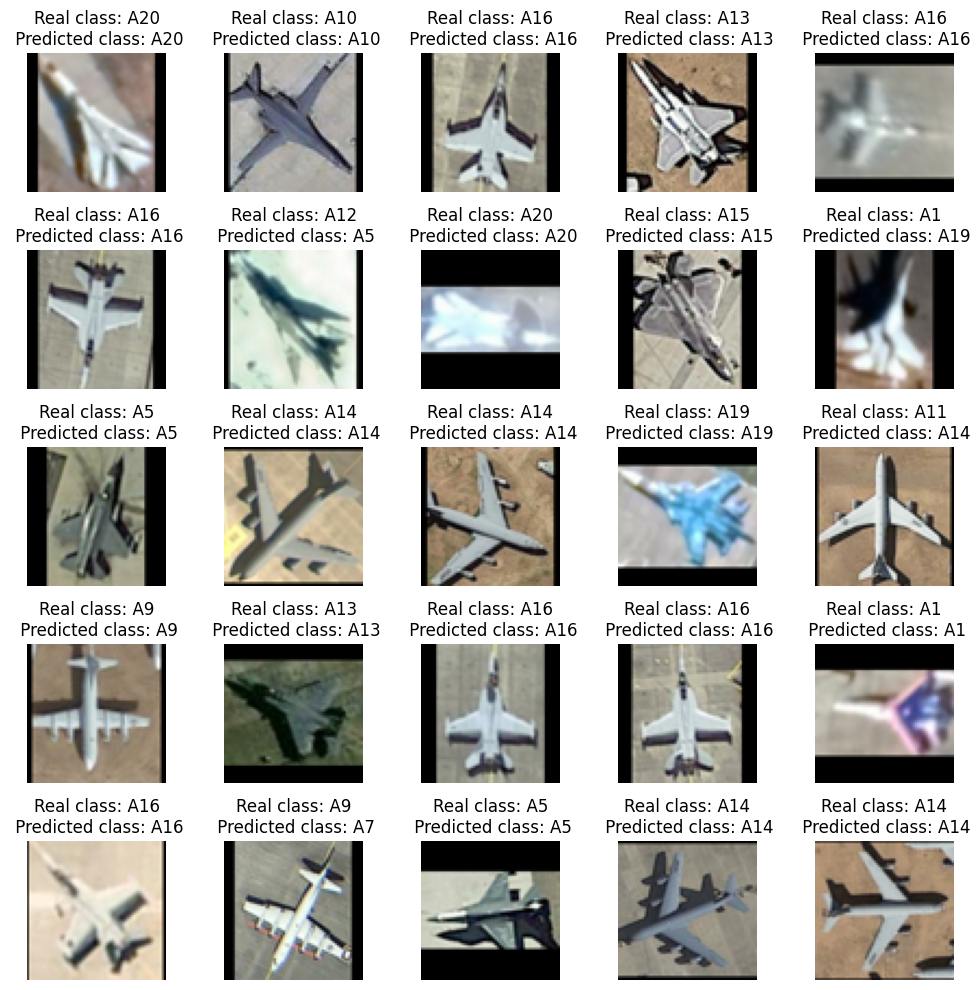

In [27]:
encoder = OneHotEncoder()
encoder.fit(original_labels.reshape(-1, 1))

y_test_np = y_test_tensor.cpu().numpy()
predictions_np = np.array(predictions)
y_orig_true = encoder.categories_[0][y_test_np.astype(int)]
y_orig_pred = encoder.categories_[0][predictions_np.astype(int)]

fig, axs = plt.subplots(5, 5, figsize=(10, 10))
axs = axs.ravel()

random_numbers = [random.randint(0, X_test.shape[0]) for _ in range(25)]

for i, rand in enumerate(random_numbers):
    axs[i].imshow(X_test[rand], cmap='gray')
    axs[i].axis('off')
    axs[i].set_title(f"Real class: {y_orig_true[rand]}\n Predicted class: {y_orig_pred[rand]}")

plt.tight_layout()
plt.show()

Accuracy: 0.8682
Precision: 0.8658
Recall: 0.8398
F1 Score: 0.8485
ROC-AUC: 0.9164
Confusion Matrix:


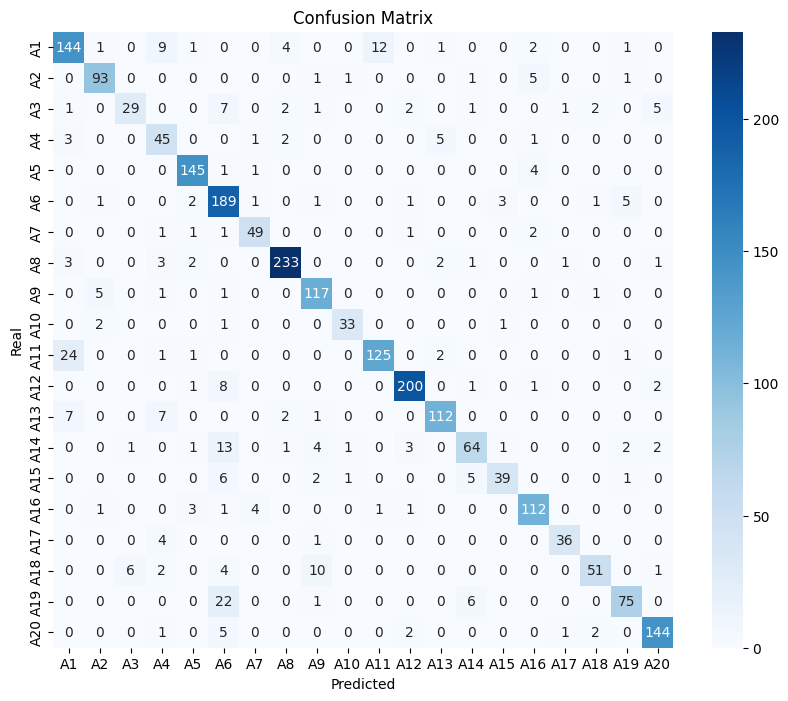

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc

accuracy = accuracy_score(y_test_np, predictions_np)

precision = precision_score(y_test_np, predictions_np, average='macro')

recall = recall_score(y_test_np, predictions_np, average='macro')

f1 = f1_score(y_test_np, predictions_np, average='macro')

conf_matrix = confusion_matrix(y_test_np, predictions_np)

roc_auc = roc_auc_score(y_test_np, torch.nn.functional.one_hot(torch.tensor(predictions_np), num_classes=len(np.unique(y_test_np))), multi_class='ovr')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("Confusion Matrix:")
plt.figure(figsize=(10, 8))
sorted_classes = sorted(encoder.categories_[0], key=lambda x: int(x[1:]))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=sorted_classes, yticklabels=sorted_classes)
plt.xlabel('Predicted')
plt.ylabel('Real')
plt.title('Confusion Matrix')
plt.show()

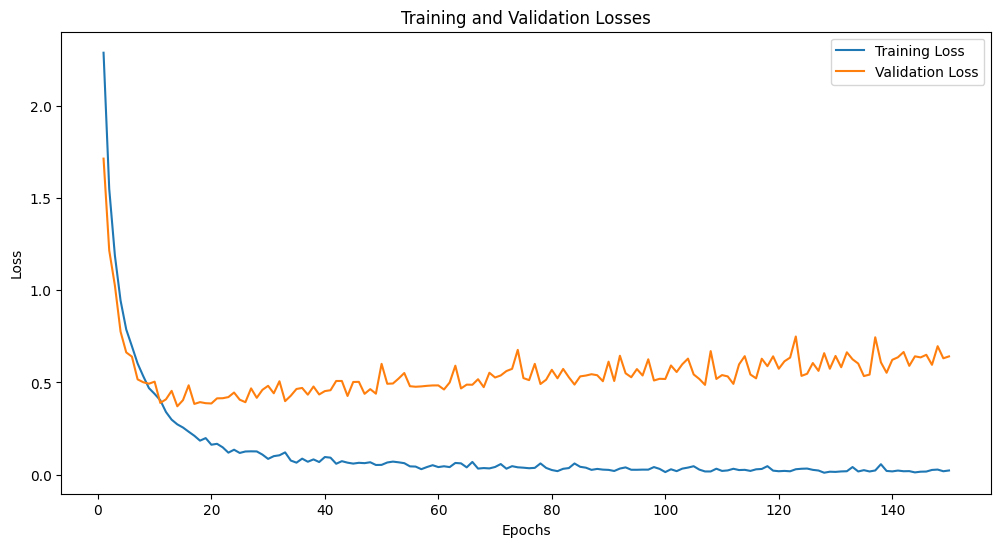

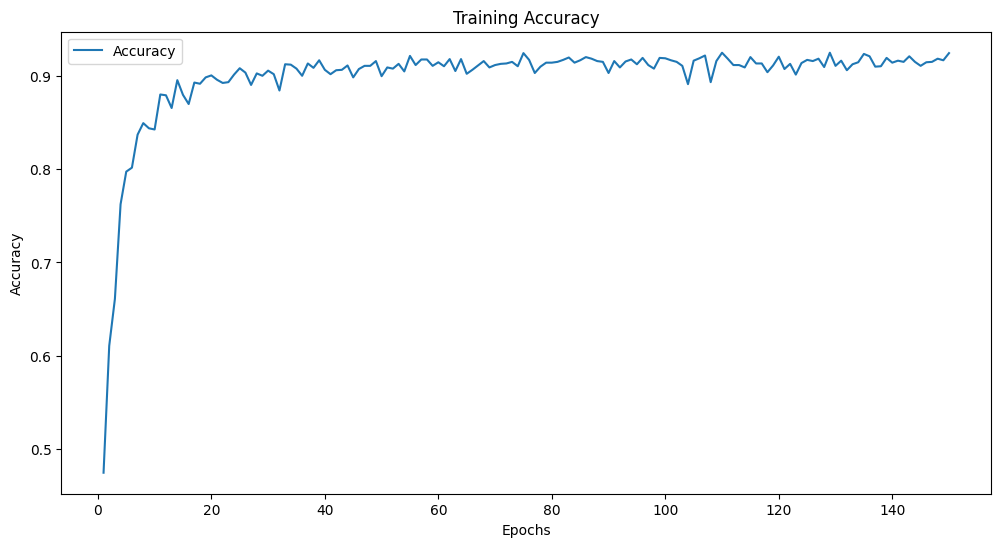

In [6]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
 
def load_data(trial_number):
    with open(f'outputs/train_losses_trial_{trial_number}.pkl', 'rb') as f:
        train_losses = pickle.load(f)
    with open(f'outputs/val_losses_trial_{trial_number}.pkl', 'rb') as f:
        val_losses = pickle.load(f)
    with open(f'outputs/accuracies_trial_{trial_number}.pkl', 'rb') as f:
        accuracies = pickle.load(f)
    
    return train_losses, val_losses, accuracies
 
def plot_losses(train_losses, val_losses):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 6))
    plt.plot(epochs, train_losses, label='Training Loss')
    plt.plot(epochs, val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Losses')
    plt.legend()
    plt.show()
 
def plot_accuracies(accuracies):
    epochs = range(1, len(accuracies) + 1)
    plt.figure(figsize=(12, 6))
    plt.plot(epochs, accuracies, label='Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training Accuracy')
    plt.legend()
    plt.show()
 
# Specify the trial number
trial_number = 216
 
# Load data
train_losses, val_losses, accuracies = load_data(trial_number)
 
# Plot losses
plot_losses(train_losses, val_losses)
 
# Plot accuracies
plot_accuracies(accuracies)

The best trial is 216
The best epoch for stopping the learning process is 11


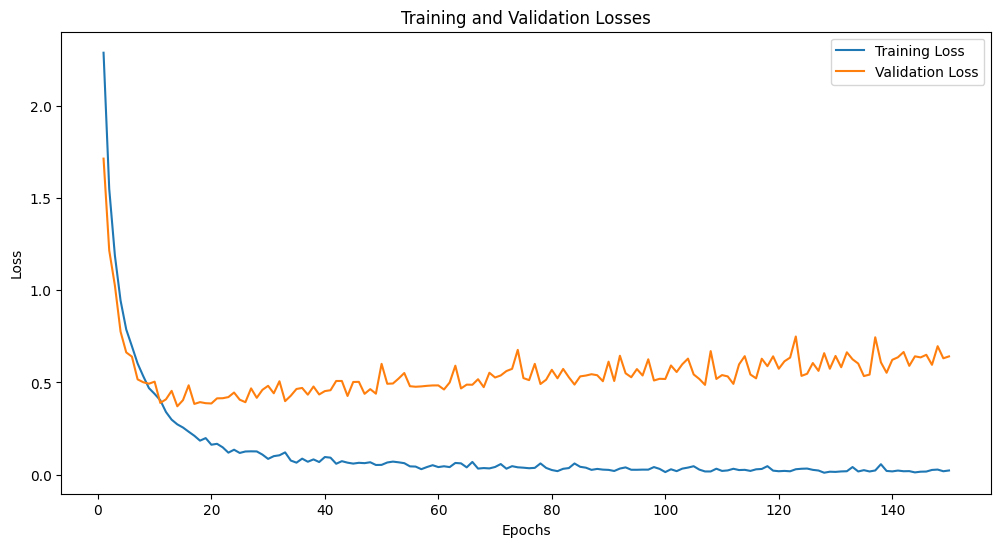

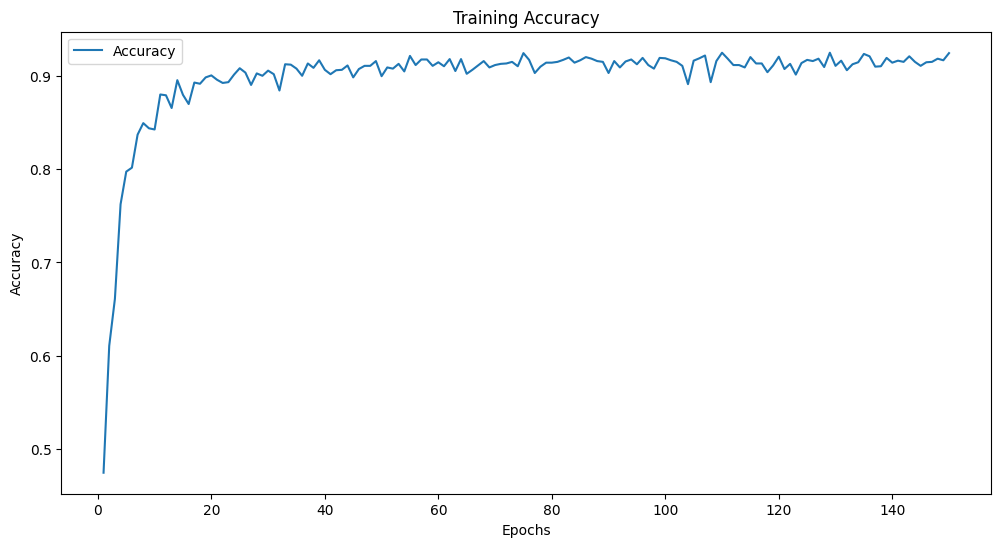

Accuracy at the best epoch (11) is 0.8801194539249146
The epoch with the highest accuracy is 110 with an accuracy of 0.9249146757679181


In [30]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt

def load_data(trial_number):
    try:
        with open(f'outputs/train_losses_trial_{trial_number}.pkl', 'rb') as f:
            train_losses = pickle.load(f)
        with open(f'outputs/val_losses_trial_{trial_number}.pkl', 'rb') as f:
            val_losses = pickle.load(f)
        with open(f'outputs/accuracies_trial_{trial_number}.pkl', 'rb') as f:
            accuracies = pickle.load(f)
        return train_losses, val_losses, accuracies
    except FileNotFoundError:
        return None, None, None

def plot_losses(train_losses, val_losses):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 6))
    plt.plot(epochs, train_losses, label='Training Loss')
    plt.plot(epochs, val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Losses')
    plt.legend()
    plt.show()

def plot_accuracies(accuracies):
    epochs = range(1, len(accuracies) + 1)
    plt.figure(figsize=(12, 6))
    plt.plot(epochs, accuracies, label='Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training Accuracy')
    plt.legend()
    plt.show()

def find_best_epoch(train_losses, val_losses, accuracies):
    best_epoch = None
    best_accuracy = 0
    for epoch in range(len(accuracies)):
        if accuracies[epoch] > best_accuracy and val_losses[epoch] < train_losses[epoch]:
            best_accuracy = accuracies[epoch]
            best_epoch = epoch + 1
    return best_epoch

def find_best_trial(trial_numbers):
    best_trial = None
    best_accuracy = 0
    for trial_number in trial_numbers:
        train_losses, val_losses, accuracies = load_data(trial_number)
        if train_losses is not None and val_losses is not None and accuracies is not None:
            for epoch in range(len(accuracies)):
                if accuracies[epoch] > best_accuracy and val_losses[epoch] < train_losses[epoch]:
                    best_accuracy = accuracies[epoch]
                    best_trial = trial_number
                    break
    return best_trial

# Specify the trial numbers to analyze (1 to 300)
trial_numbers = list(range(1, 301))

# Find the best trial
best_trial = find_best_trial(trial_numbers)
print(f"The best trial is {best_trial}")

if best_trial is not None:
    # Load data for the best trial
    train_losses, val_losses, accuracies = load_data(best_trial)

    # Find the best epoch for stopping the learning process
    best_epoch = find_best_epoch(train_losses, val_losses, accuracies)
    print(f"The best epoch for stopping the learning process is {best_epoch}")

    # Plot losses for the best trial
    plot_losses(train_losses, val_losses)

    # Plot accuracies for the best trial
    plot_accuracies(accuracies)

    # Display accuracy for the best epoch
    print(f"Accuracy at the best epoch ({best_epoch}) is {accuracies[best_epoch-1]}")

    # Find and display the epoch with the highest accuracy
    highest_accuracy_epoch = accuracies.index(max(accuracies)) + 1
    print(f"The epoch with the highest accuracy is {highest_accuracy_epoch} with an accuracy of {max(accuracies)}")
else:
    print("No valid trials found.")
